# Load & Parse Data

In [3]:
from utils.parse_data import parse_dataset
from pathlib import Path

data_path = Path('./data/train_pooled_stratified_share_vc')
X_train, Y_train, X_test, Y_test, device = parse_dataset(root_dir=data_path, M=50, H=3, normalize=True, stride=1, test_ratio=0.2,
                                                         test_subjects=None, random_state=42, verbose=True)

Using dataset path: data/train_pooled_stratified_share_vc
Loading dataset with fixed schema settings...
Scanning and loading dataset (optimized fixed schema mode)...
Loaded: 2880 runs from 8 subjects
Subjects: ['subjA2s60K-Hhm', 'subjOenz4SHyaO', 'subjQX6R7rImeb', 'subjoVC0sHUB_P', 'subjqFdsBbuiHF', 'subjsRowSC6dc4', 'subjtySNgRhV65', 'subjxpYwO4azeZ']
Successfully loaded runs: 2880
Loading time: 7.21 seconds
Device: cuda
Normalizing dataset...
Building sliding windows...
Splitting by subject...
Train subjects: ['subjoVC0sHUB_P', 'subjqFdsBbuiHF', 'subjQX6R7rImeb', 'subjxpYwO4azeZ', 'subjtySNgRhV65', 'subjOenz4SHyaO']
Test subjects : ['subjsRowSC6dc4', 'subjA2s60K-Hhm']
Train runs: 2144
Test runs : 736
Final shapes - Train: (373056, 50, 23), (373056, 3, 23) | Test: (128064, 50, 23), (128064, 3, 23)


In [4]:
from models.transformer import transformer_model_generator, TransformerPredictorAPI

# Build transformer

model = transformer_model_generator(
    n_roi=X_train.shape[2],
    M=50,
    H=3,
    d_model=64,
    nhead=4,
    num_layers=2,
    dropout=0.1,
)

model = model.to(device)

### Read the Model

In [ ]:
import torch
from pathlib import Path

from utils.validation import load_model_from_weights_save
from models.transformer import transformer_model_generator

# weights_path = Path("saves") / "trained_model_weights" / "transformer_final_vc.pt"
# model = load_model_from_weights_save(weights_path)

checkpoint_path = Path("saves/trained_model_weights/transformer_final_vc.pt")
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

/tmp/ipykernel_2085324/218776429.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


TransformerForecastModel(
  (input_proj): Linear(in_features=23, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_layer): Linear(in_features=64, out_features=69, bias=True)
)

In [8]:
import numpy as np

X = np.concatenate([X_train, X_test], axis=0)
Y = np.concatenate([Y_train, Y_test], axis=0)

Histogram Method

In [9]:
from utils.measures import fit_histogram_proba_adapter

# Wrap with API
config = {
    "window_size": 50,
    "predict_step": 3,
    "output_horizon": 3,
    "input_dim": X_train.shape[2],
    "d_model": 64,
    "nhead": 4,
    "num_layers": 2,
    "dropout": 0.1,
}

model_api = TransformerPredictorAPI(
    model=model,
    config=config,
    stats={},
    device=device,
)

# Build histogram likelihood adapter
prob_model = fit_histogram_proba_adapter(
    base_model=model_api,
    X_calib=X,
    Y_calib=Y,
    n_bins=50,
    flatten_input=False,
)

Neural Network Method

In [9]:
from utils.measures import FlowPredictorAPI

prob_model = FlowPredictorAPI(
    model_obj=model,
    device=device,
)

prob_model.fit_residual_std(
    X_calib=X,
    Y_calib=Y,
    batch_size=512,
)

In [43]:
import importlib
import utils.measures  

importlib.reload(utils.measures)

<module 'utils.measures' from '/home/ab126/projects/fmri_connectivity/fmri_forecasting/utils/measures.py'>

In [10]:
from utils.measures import compute_di_from_log_prob_api

reduction_mode="zero" # zero shuffle
DI_flow = compute_di_from_log_prob_api(
    model=prob_model,
    X=X,
    Y=Y,
    horizon_idx=0,
    reduction_mode=reduction_mode,
)

Computing DI: 100%|██████████| 529/529 [04:33<00:00,  1.94it/s]


In [ ]:
# Debugging

from utils.measures import make_reduced_input
import numpy as np

R = X_test.shape[2]
for i in range(5):
    X_red = make_reduced_input(X, source_roi=i, mode=reduction_mode)
    pred_full = prob_model.predict(X)
    pred_red = prob_model.predict(X_red)

    delta = np.mean(np.abs(pred_full - pred_red), axis=(0, 1))
    print(i, delta)

0 [0.52376956 0.04213888 0.0722006  0.04447552 0.05380813 0.04758447
 0.04350735 0.05256556 0.05299747 0.04441048 0.04379006 0.0443283
 0.04473888 0.04778455 0.04402281 0.05275939 0.04023214 0.06237276
 0.04739952 0.04336578 0.04244765 0.04937468 0.05919245]
1 [0.04484963 0.52856755 0.05695906 0.06667634 0.03836866 0.05785711
 0.04760444 0.05073078 0.04268847 0.04857885 0.05637468 0.05016348
 0.06438343 0.05318438 0.06055968 0.03704461 0.0376104  0.05423811
 0.04465554 0.07612176 0.0594804  0.03565586 0.05437626]
2 [0.08944735 0.05943373 0.49792045 0.04053968 0.06028938 0.05007482
 0.04823194 0.05225479 0.04923553 0.04623801 0.05113742 0.04305987
 0.04633939 0.04417352 0.04468162 0.04607687 0.04502963 0.05785779
 0.04787349 0.04563301 0.04907935 0.04477734 0.04774204]
3 [0.04510715 0.07879801 0.05286481 0.5479801  0.05202479 0.06155669
 0.04783202 0.05807351 0.04380256 0.05074037 0.04681308 0.05101082
 0.05288989 0.04601757 0.04408674 0.04249169 0.05121229 0.05482338
 0.04642142 0.0612

In [11]:
DI_flow.shape

# DI_flow


(23, 23)

In [41]:
import importlib
import utils.plotting  

importlib.reload(utils.plotting)

<module 'utils.plotting' from '/home/ab126/projects/fmri_connectivity/fmri_forecasting/utils/plotting.py'>

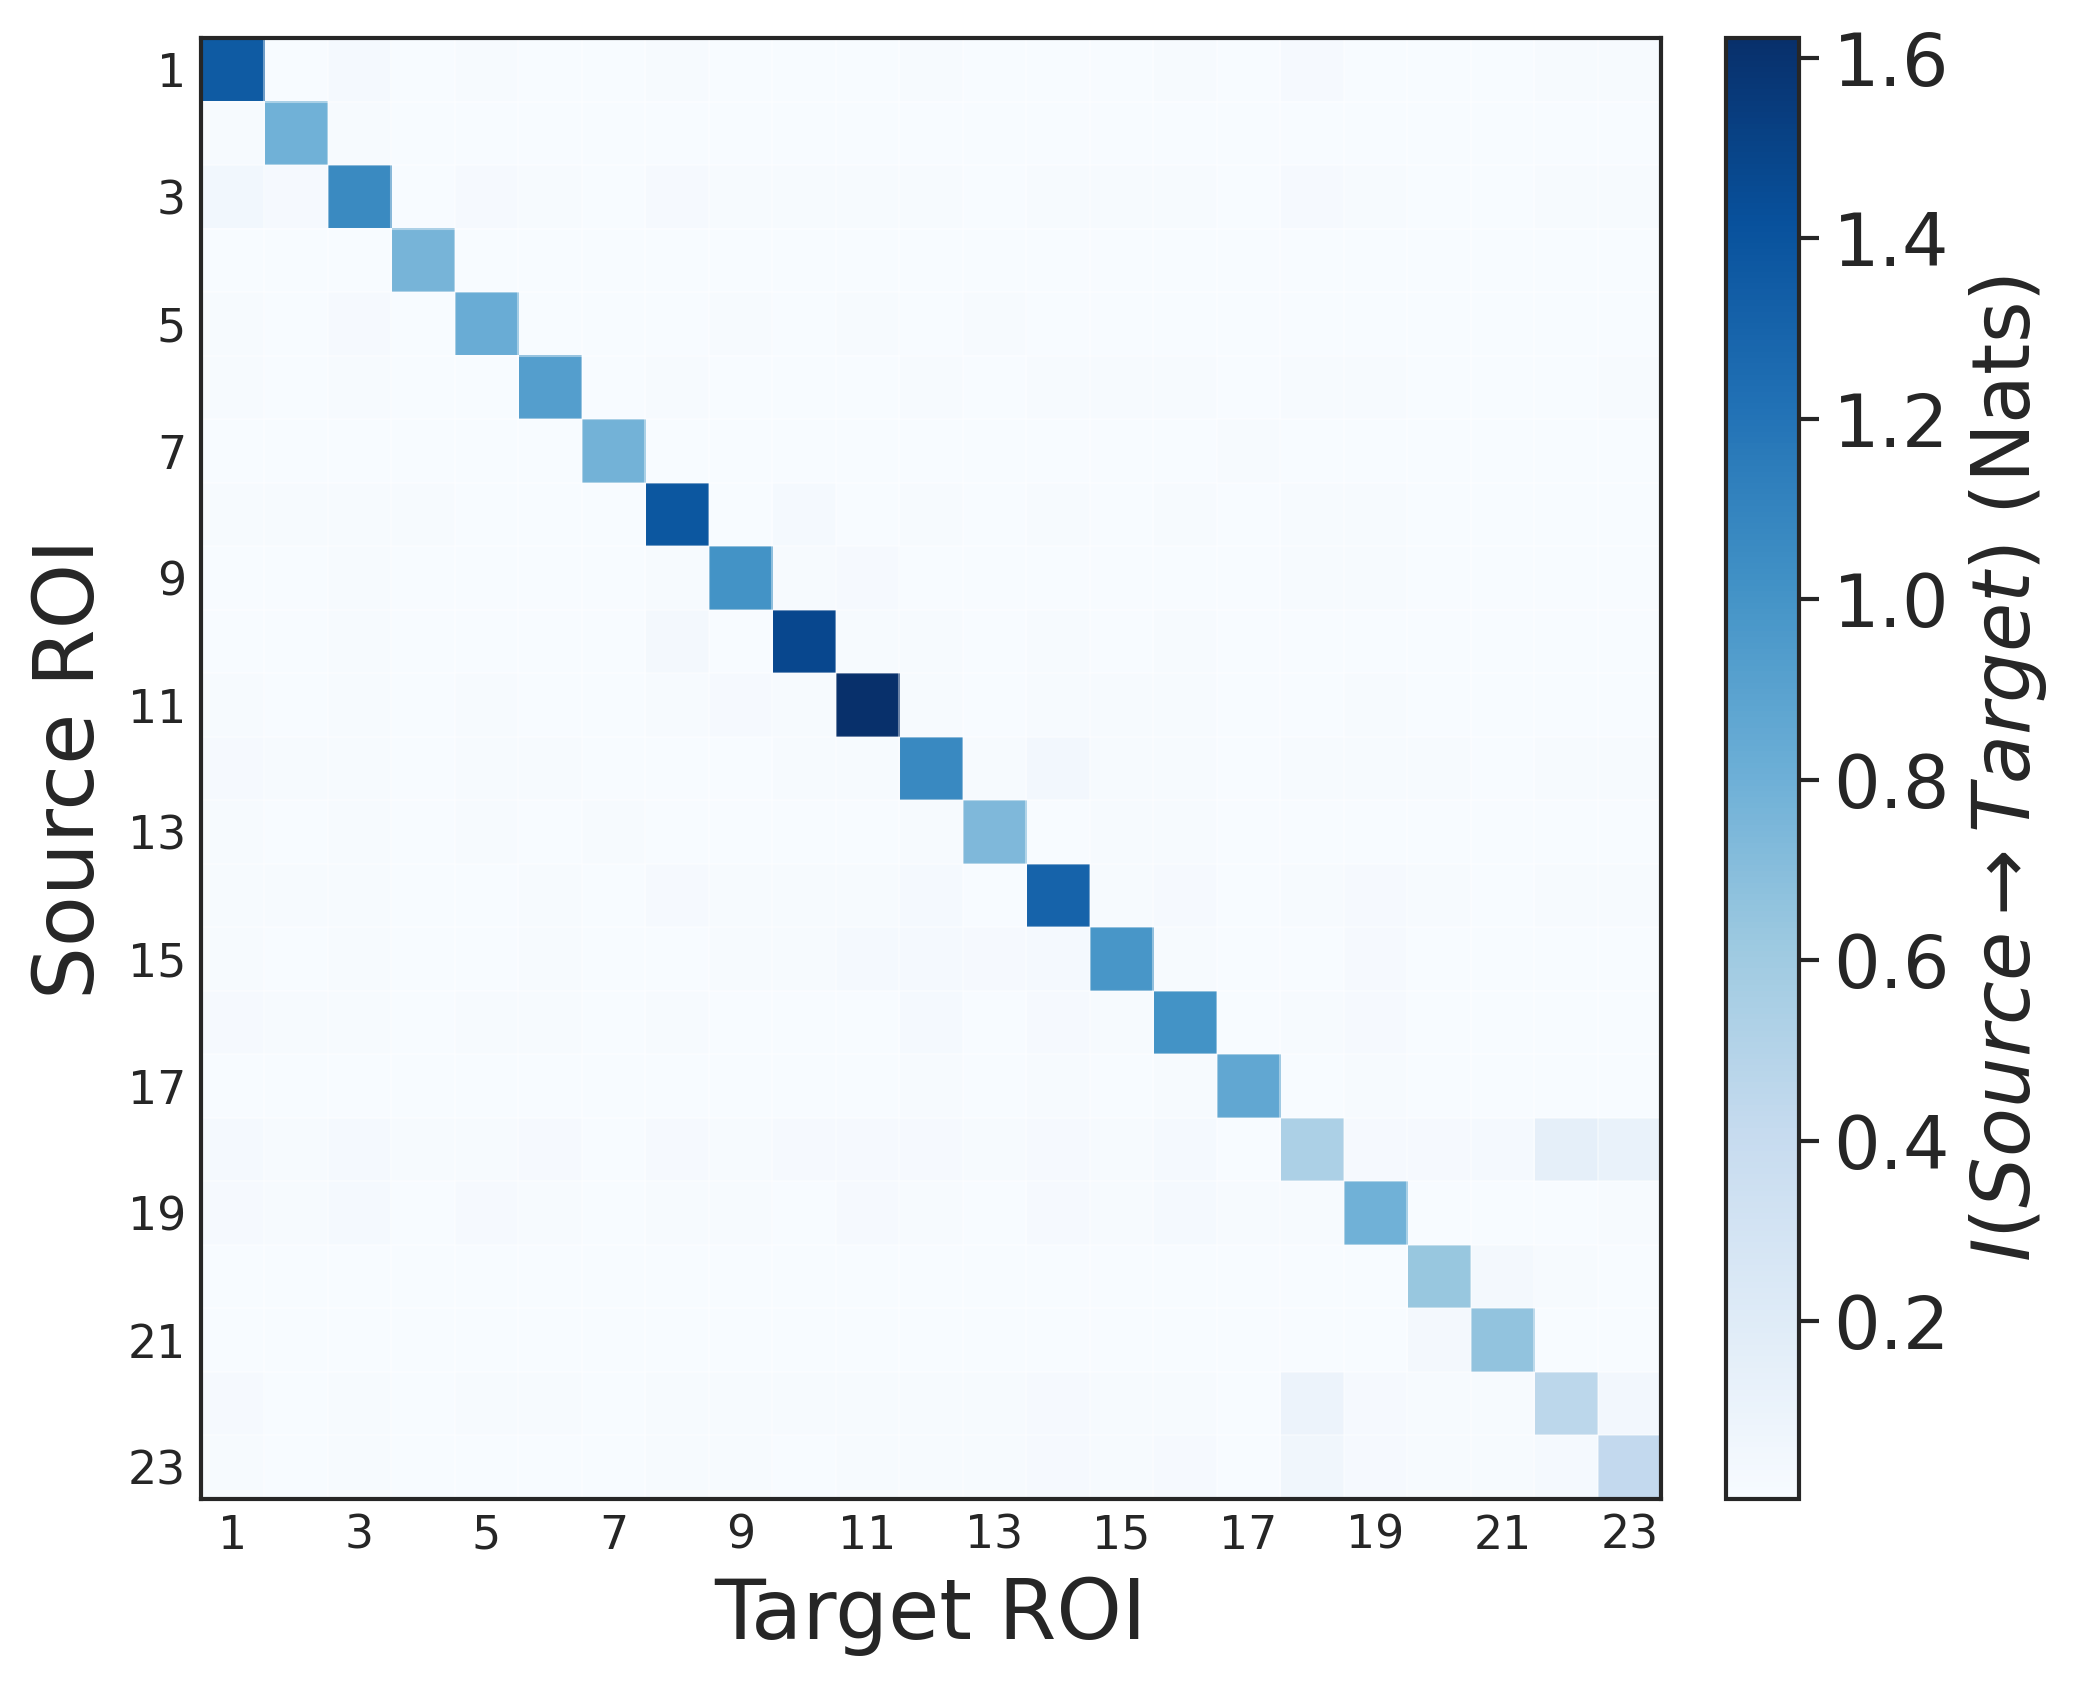

(<Figure size 2100x1800 with 2 Axes>,
 <Axes: xlabel='Target ROI', ylabel='Source ROI'>)

In [42]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import seaborn as sns

from utils.plotting import plot_di_mat


cmap = sns.light_palette("#2166ac", as_cmap=True)
cmap="Blues"

plot_di_mat(
    DI_flow,
    cmap=cmap,
    title="",
    save_path=Path("saves/di_flow.png"),
    show=True,
    dpi=300,
)

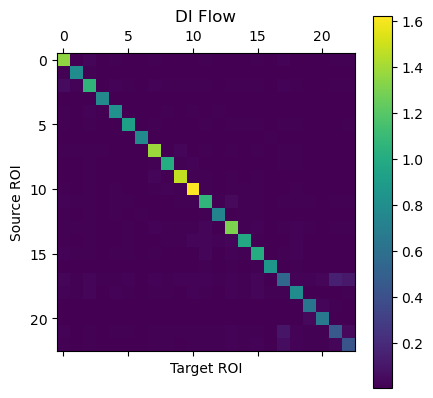

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path



plt.matshow(np.abs(DI_flow) )
plt.colorbar()
plt.title("DI Flow")
plt.xlabel("Target ROI")
plt.ylabel("Source ROI")
plt.show()

fig = plt.gcf()
Path("saves").mkdir(exist_ok=True)

plt.savefig(Path("saves/di_flow.png"))

## Conditional Entropy

In [3]:
import importlib
import utils.plotting

importlib.reload(utils.plotting)

<module 'utils.plotting' from '/home/ab126/projects/fmri_connectivity/fmri_forecasting/utils/plotting.py'>

In [ ]:
from utils.measures import compute_marginal_entropy_histogram, compute_conditional_entropy_from_log_prob_api

H_marg = compute_marginal_entropy_histogram(
    Y_test,
    horizon_idx=0,
    n_bins=50,
)

H_cond = compute_conditional_entropy_from_log_prob_api(
    model=prob_model,
    X=X_test,
    Y=Y_test,
    horizon_idx=0,
)

eta_roi = 1 - H_cond / (H_marg + 1e-12)
eta_roi_percent = 100 * eta_roi

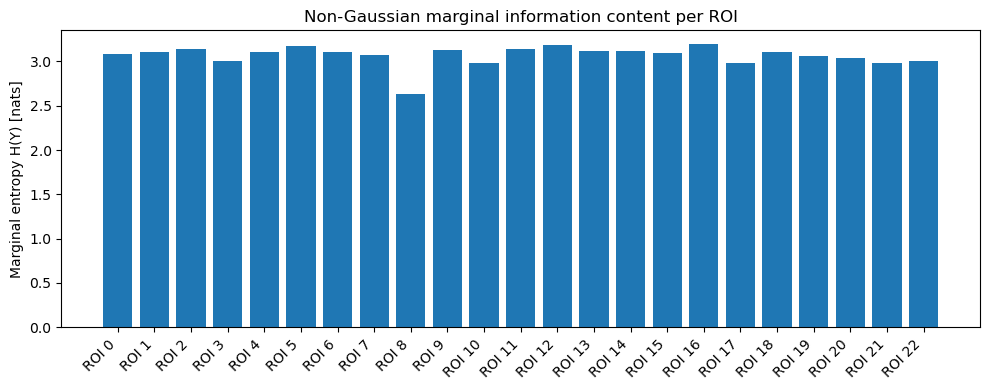

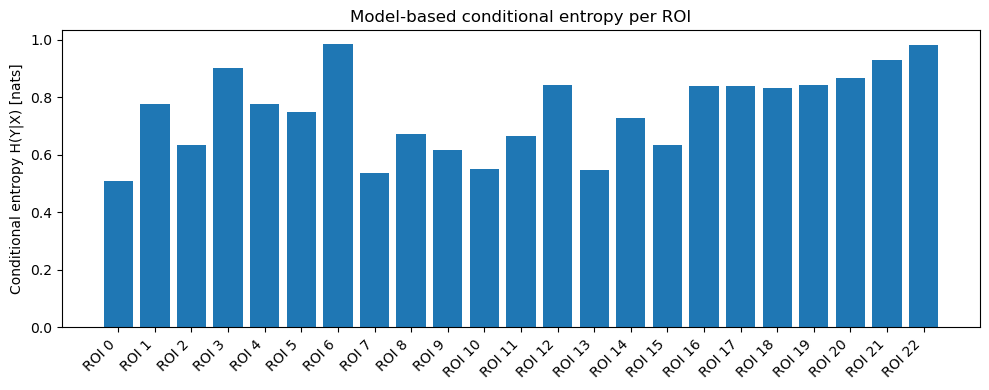

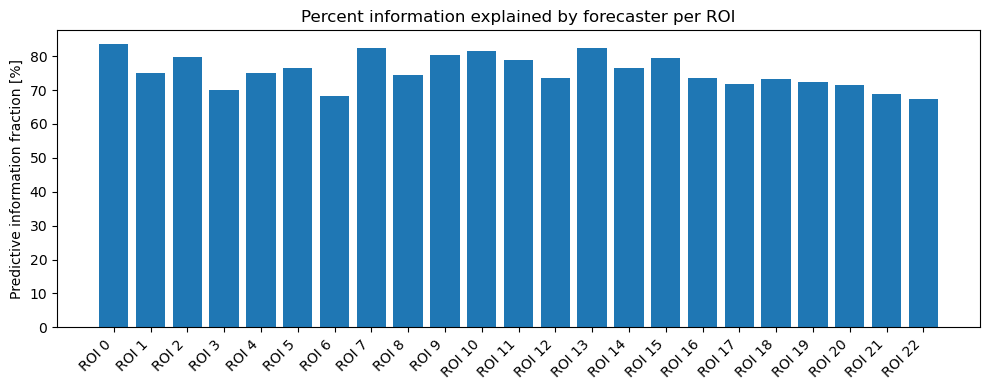

In [24]:
from utils.plotting import plot_per_roi_bar

roi_labels = None

plot_per_roi_bar(
    H_marg,
    roi_labels=roi_labels,
    ylabel="Marginal entropy H(Y) [nats]",
    title="Non-Gaussian marginal information content per ROI"
)

plot_per_roi_bar(
    H_cond,
    roi_labels=roi_labels,
    ylabel="Conditional entropy H(Y|X) [nats]",
    title="Model-based conditional entropy per ROI"
)

plot_per_roi_bar(
    eta_roi_percent,
    roi_labels=roi_labels,
    ylabel="Predictive information fraction [%]",
    title="Percent information explained by forecaster per ROI"
)

In [57]:
import importlib
import utils.plotting

importlib.reload(utils.plotting)

<module 'utils.plotting' from '/home/ab126/projects/fmri_connectivity/fmri_forecasting/utils/plotting.py'>

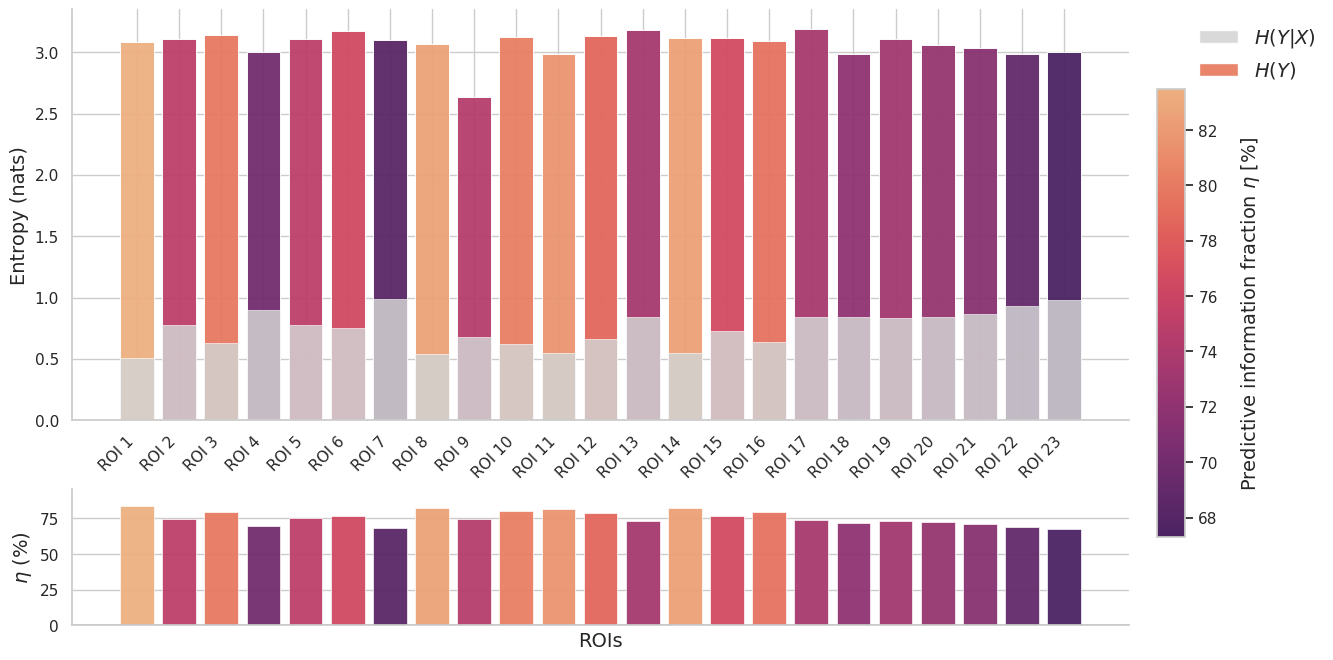

In [58]:
from utils.plotting import plot_entropy_decomposition
import seaborn as sns

roi_labels = None

sns.set_theme(style="whitegrid")

eta_percent = plot_entropy_decomposition(
    H_marg,
    H_cond,
    roi_labels=roi_labels,
    cmap="flare_r",
)

In [59]:
# Specificity

for n_bins in [20, 30, 50, 75, 100, 1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000, 500000, 1000000]:
    H_marg = compute_marginal_entropy_histogram(Y_test, n_bins=n_bins)
    eta_roi = 1 - H_cond / (H_marg + 1e-12)
    print(n_bins, np.nanmean(eta_roi))

20 0.651361
30 0.7060911
50 0.7549141
75 0.7835375
100 0.80011594
1000 0.876051
2000 0.8887301
5000 0.90191674
10000 0.9098971
20000 0.9165492
50000 0.92363167
100000 0.9277908
200000 0.93088335
500000 0.93341005
1000000 0.9344224


In [60]:
print(f"Mean H(Y): {np.mean(H_marg):.2f} nats")
print(f"Mean H(Y|X): {np.mean(H_cond):.2f} nats")
print(f"Mean H(Y) - H(Y|X): {np.mean(H_marg - H_cond):.2f} nats")
print(f"Mean eta: {np.mean(eta_percent):.2f}%")


Mean H(Y): 11.45 nats
Mean H(Y|X): 0.75 nats
Mean H(Y) - H(Y|X): 10.70 nats
Mean eta: 75.49%
